In [135]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


![ex2_2.png](ex2_2.png)

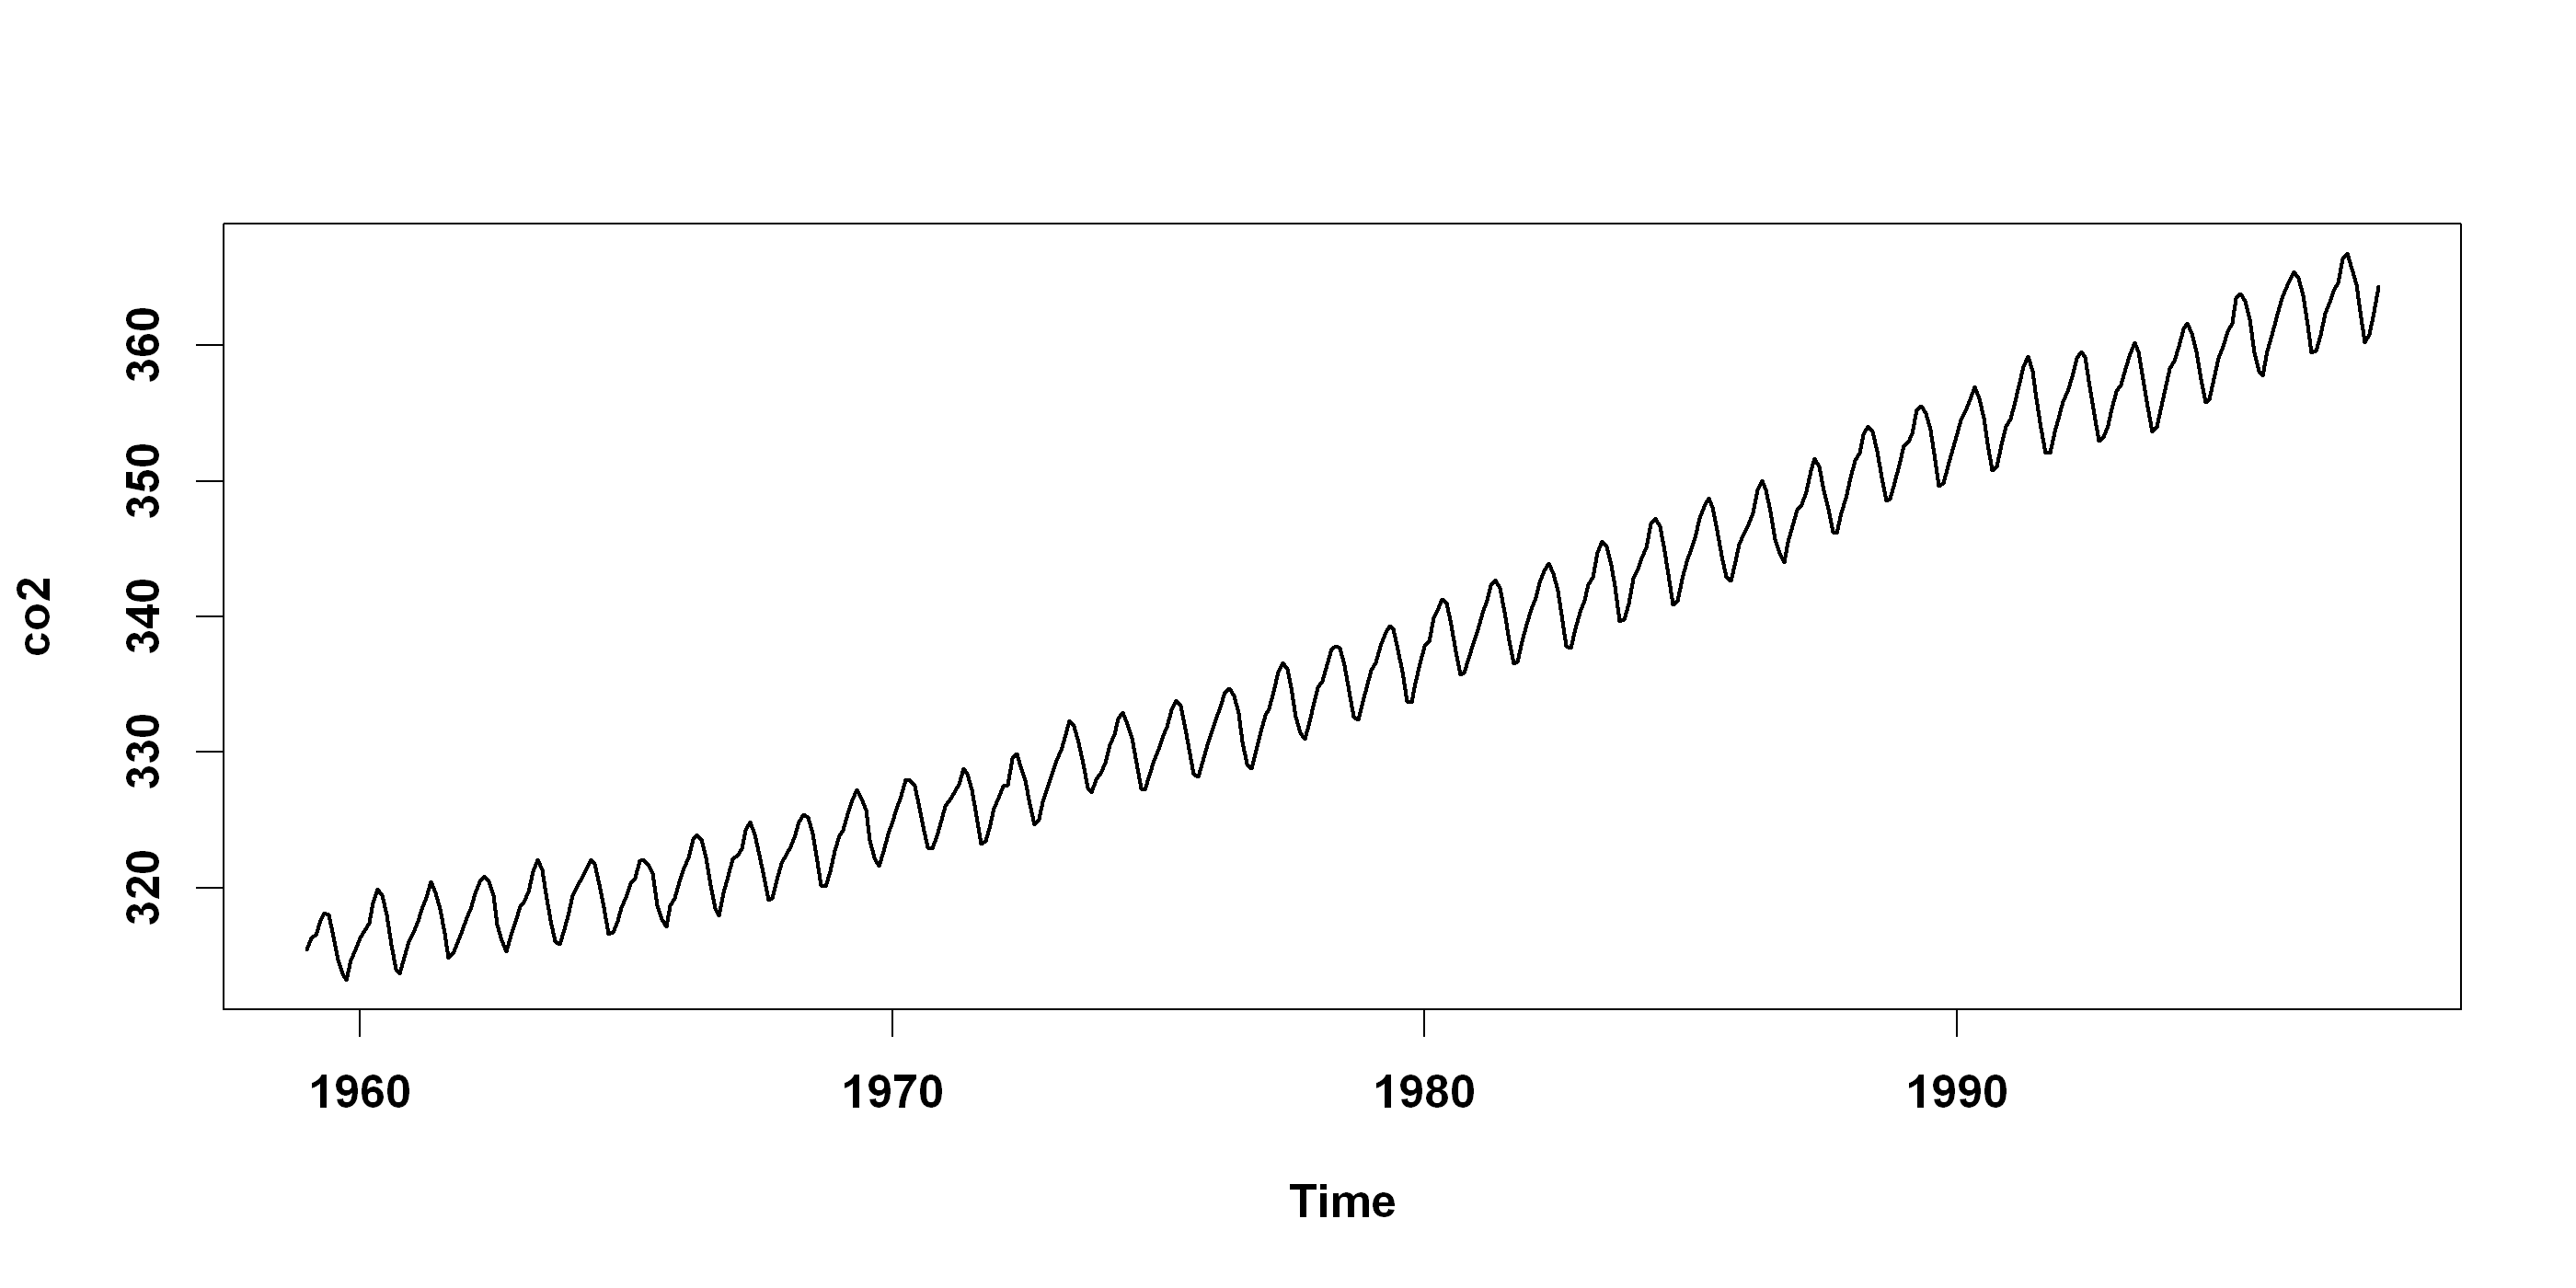

In [136]:
data(co2)
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2)
plot(co2,lwd = 2)


### a
Non-stationary, there is a strong trend, and there is a strong seasonality (which are the components as well)

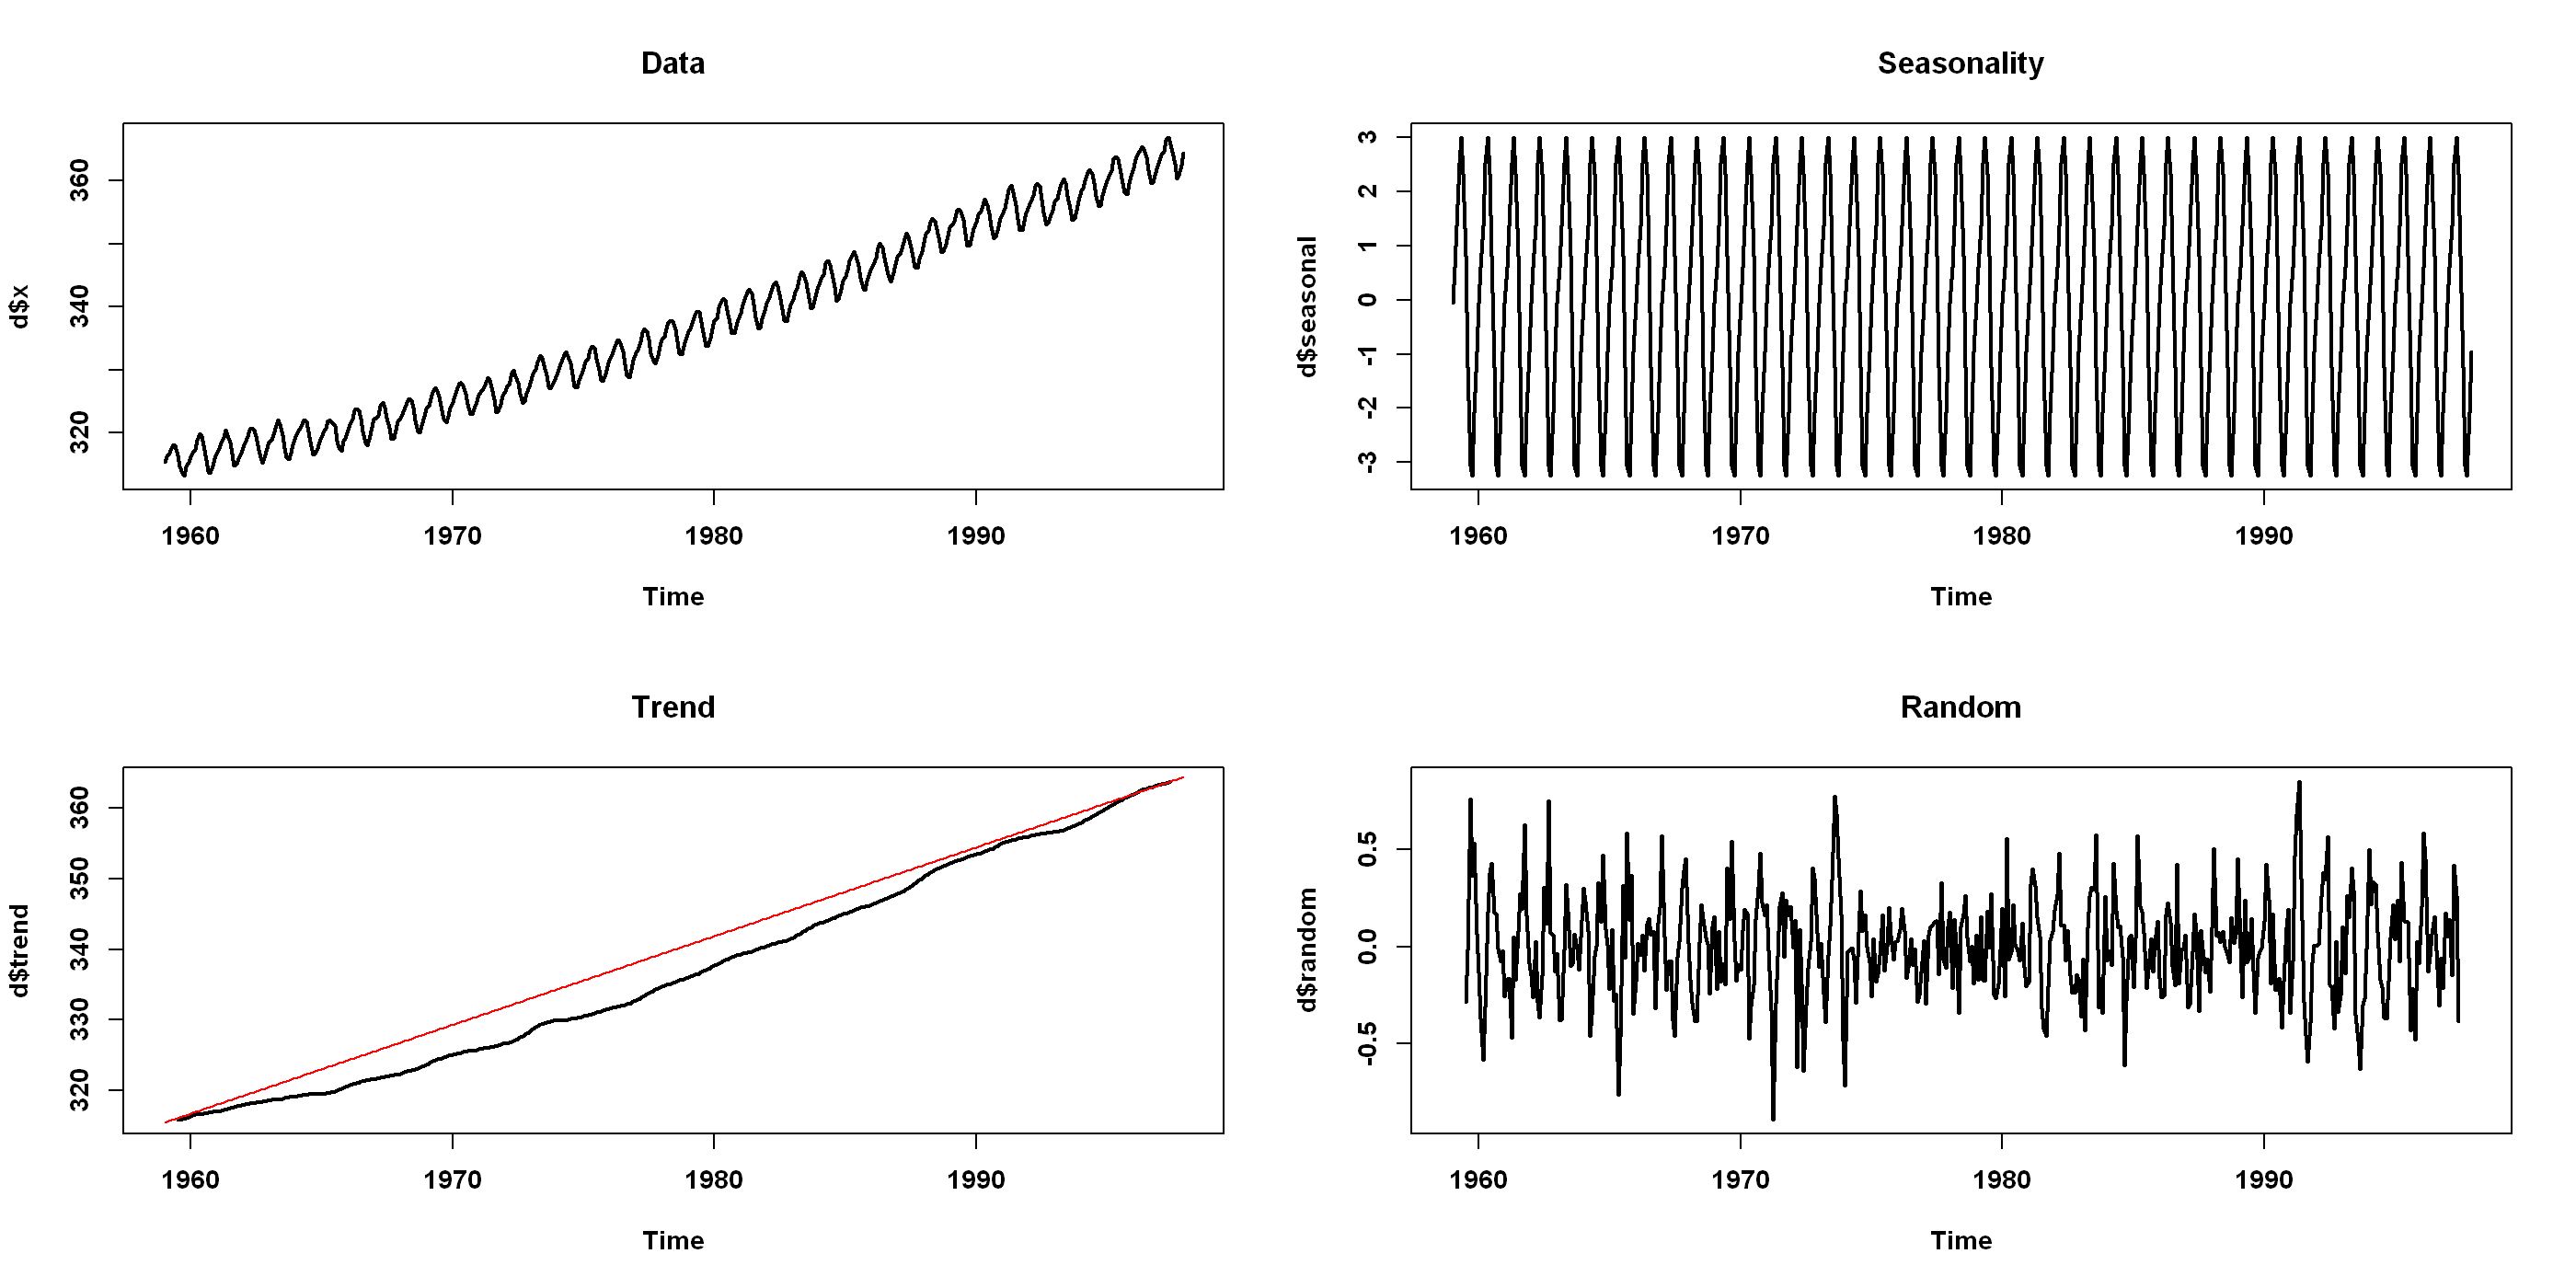

In [137]:
d = decompose(co2,type = "additive");
n = length(co2)
x = seq(1, n, length.out = n)
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(2,2))
plot(d$x,lwd = 2,main = "Data")
plot(d$seasonal,lwd = 2,main = "Seasonality")
plot(d$trend,lwd = 2,main = "Trend")
lines(as.numeric(time(co2)),(co2[n]-co2[1])/n * x + co2[1],col="Red")
plot(d$random,lwd=2,main="Random")



### b

The trend is very close to being linear (as shown in the figure), there are slight devitions, one might argue that the trend is quasi-linear, where the non-linear part is very small in proportion to the linear one, where the non-linear part is appears to be almost convex.

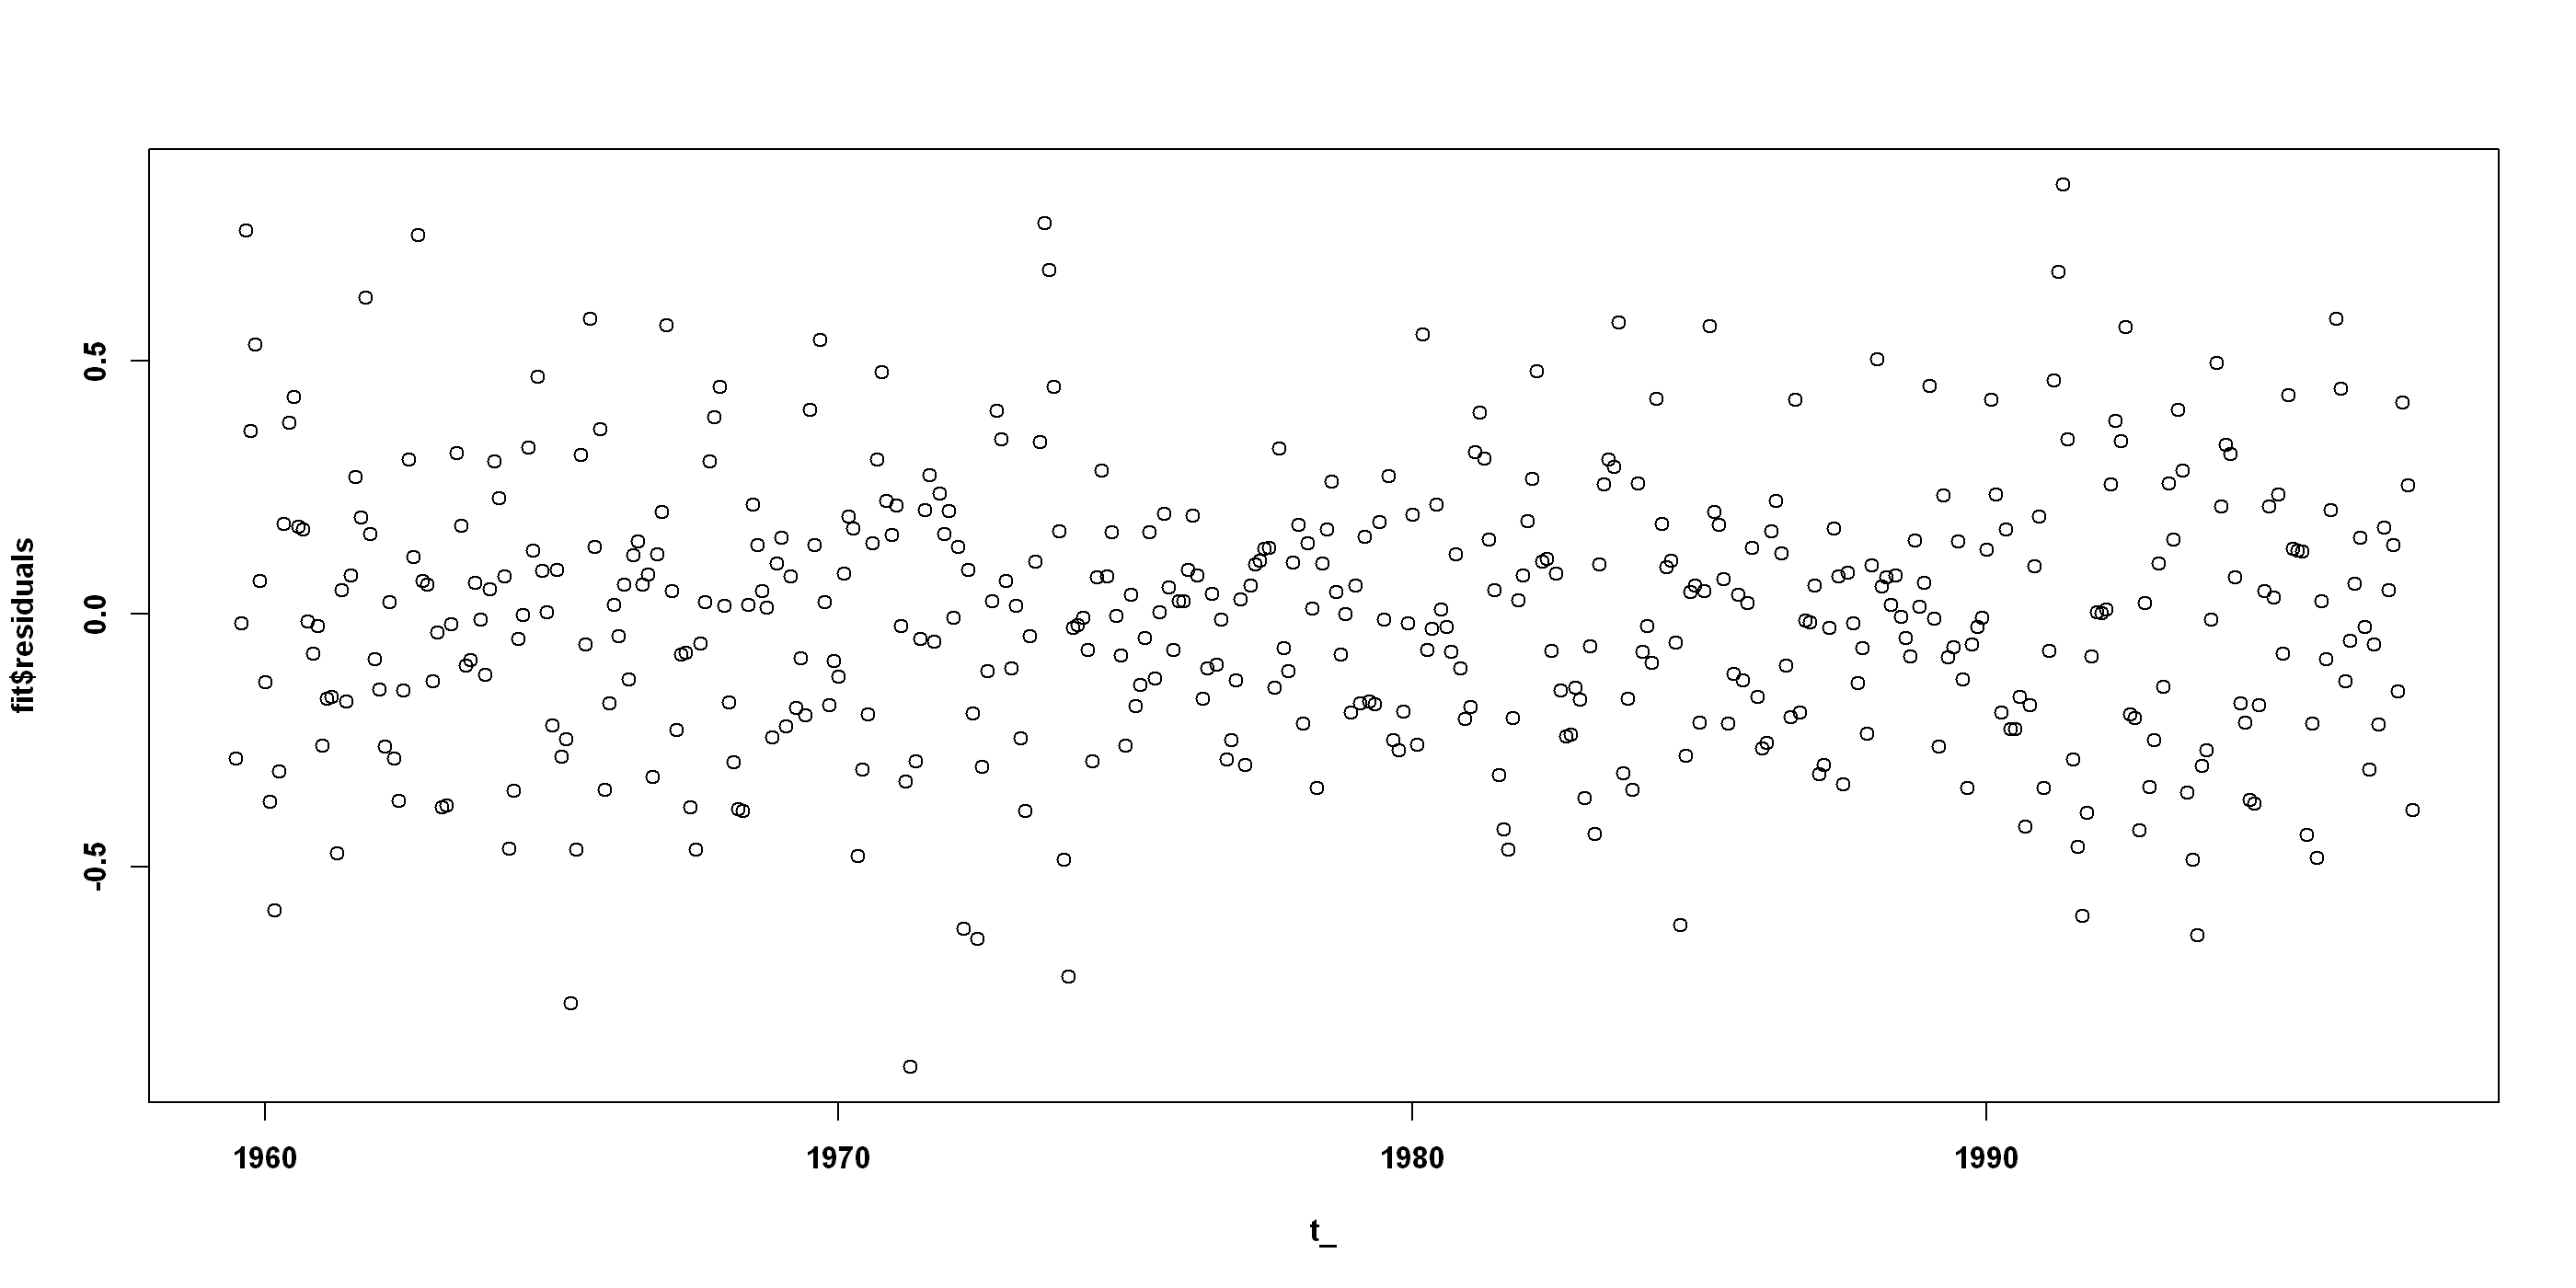

[1] 456

[1] 468

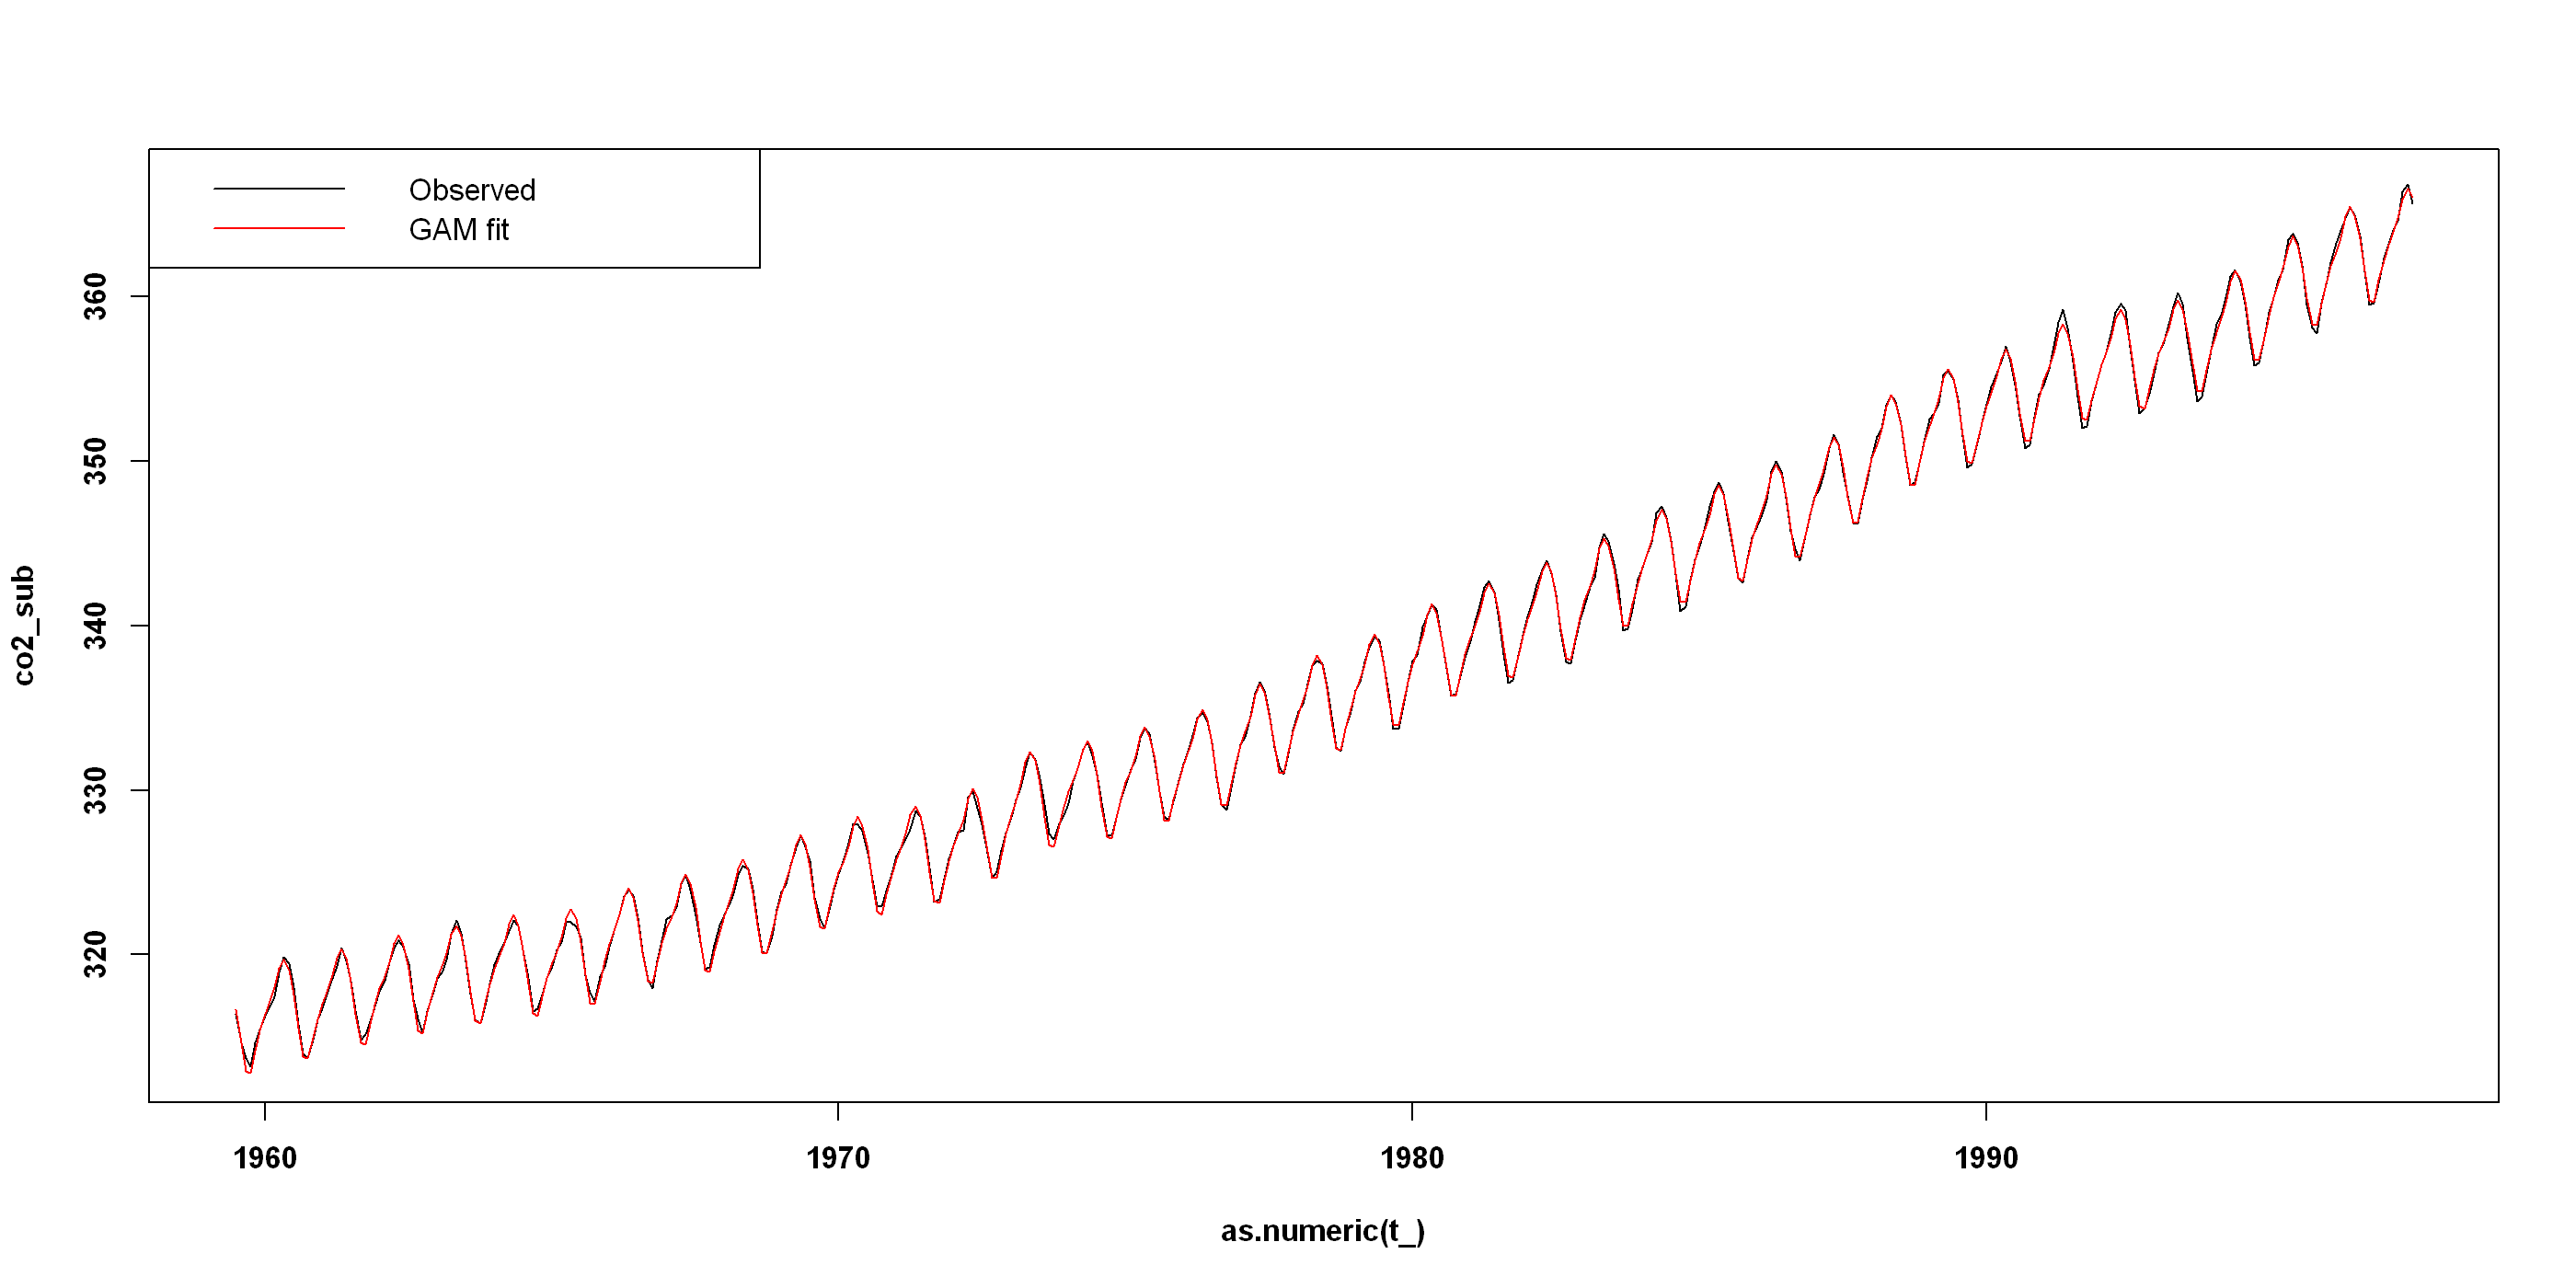

In [158]:
library(mgcv)
# tr<-as.numeric(d$trend)
# months <- as.numeric((time(co2))-as.numeric(start(co2)[1]))*12
# months[1:12]
mm <- rep(c("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"))
mm <- factor(rep(mm,n/12),levels=mm)
fit<-gam(co2~ s(tr) + mm)
# print(fit)


n_lag = length(fit$fitted.values)
co2_sub = co2[7:(n-6)]
t_ = time(co2)[7:(n-6)]

par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(1,1))

plot(t_,fit$residuals)
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(1,1))

plot(as.numeric(t_),co2_sub,col="Black",type='l')
lines(as.numeric(t_),fit$fitted.values,col="Red")
legend("topleft", legend=c("Observed","GAM fit"), col=c("black","red"), lty=1)

length(fit$fitted.values) 
length(co2)